<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Descomposici%C3%B3n_Can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # **Descomposición Canónica**

**1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.**


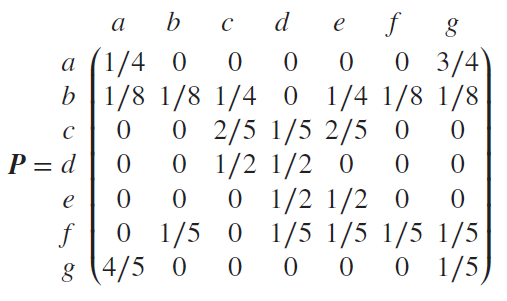

In [1]:
import numpy as np
from sympy import Matrix , init_printing
import sympy as sp
import networkx as nx
import matplotlib.cm
import matplotlib.pyplot as plt

In [31]:
P = sp.Matrix([
    [sp.Rational(1,4), 0,                 0,                 0,                 0,                 0, sp.Rational(3,4)],
    [sp.Rational(1,8), sp.Rational(1,8),  sp.Rational(1,4),  0,                 sp.Rational(1,4),  sp.Rational(1,8), sp.Rational(1,8)],
    [0,                 0,                 sp.Rational(2,5),  sp.Rational(1,5),  sp.Rational(2,5),  0,                 0],
    [0,                 0,                 sp.Rational(1,2),  sp.Rational(1,2),  0,                 0,                 0],
    [0,                 0,                 0,                 sp.Rational(1,2),  sp.Rational(1,2),  0,                 0],
    [0,                 sp.Rational(1,5),  0,                 sp.Rational(1,5),  sp.Rational(1,5),  sp.Rational(1,5), sp.Rational(1,5)],
    [sp.Rational(4,5), 0,                 0,                 0,                 0,                 0, sp.Rational(1,5)]
])

print("Matriz de Transición de P:")
print("\n")
P

Matriz de Transición de P:




Matrix([
[1/4,   0,   0,   0,   0,   0, 3/4],
[1/8, 1/8, 1/4,   0, 1/4, 1/8, 1/8],
[  0,   0, 2/5, 1/5, 2/5,   0,   0],
[  0,   0, 1/2, 1/2,   0,   0,   0],
[  0,   0,   0, 1/2, 1/2,   0,   0],
[  0, 1/5,   0, 1/5, 1/5, 1/5, 1/5],
[4/5,   0,   0,   0,   0,   0, 1/5]])

Ahora bien, procedams a obtener el *Diagrama de Transiciones* para nuestra matriz P

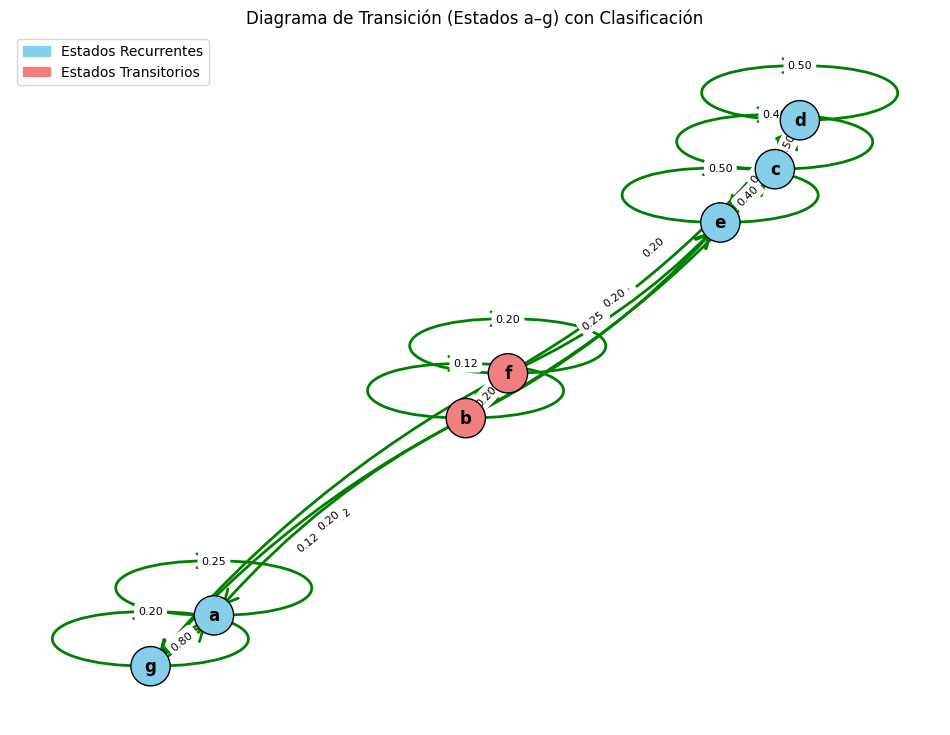

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Crear grafo dirigido
G = nx.DiGraph()

# Estados (a–g)
labels = ['a','b','c','d','e','f','g']
n = len(labels)

# Definir P_np si no está ya definido
# Assuming P (sympy Matrix) is defined in a preceding cell
P_np = np.array(P.tolist(), dtype=float)

# Añadir nodos
for i in range(n):
    G.add_node(i)

# Añadir aristas automáticamente según la matriz P
for i in range(n):
    for j in range(n):
        if P_np[i, j] > 0: # Use P_np for numerical comparison
            G.add_edge(i, j, label=P_np[i, j]) # Use P_np for label

# Usar un algoritmo de layout para calcular las posiciones de los nodos
# nx.spring_layout() es una buena opción para un layout general.
pos = nx.spring_layout(G)

plt.figure(figsize=(12,9))

# Define colors for recurrent and transient states
recurrent_color = 'skyblue'
transient_color = 'lightcoral'

# Create a list of colors for each node based on its state type
node_colors = []
for i in range(n):
    if i in recurrent_states: # recurrent_states is a set of indices from cell 986f13ca
        node_colors.append(recurrent_color)
    elif i in transient_states: # transient_states is a set of indices from cell 986f13ca
        node_colors.append(transient_color)
    else:
        node_colors.append('gray') # Fallback color, though all states should be classified

# Dibujar nodos
nx.draw_networkx_nodes(G, pos,
    node_color=node_colors, # Usar los colores generados
    node_size=800,
    edgecolors='black'
)

# Dibujar aristas
nx.draw_networkx_edges(G, pos,
    arrows=True,
    arrowstyle='->',
    arrowsize=25, # Increased arrow size
    width=2,      # Added width to the arrows
    edge_color='green', # Flechas verdes
    connectionstyle='arc3,rad=0.1'
)

# Etiquetas de nodos
nx.draw_networkx_labels(G, pos,
    labels={i: labels[i] for i in range(n)},
    font_size=12,
    font_weight='bold'
)

# Etiquetas de probabilidades
edge_labels = {(u, v): f'{d["label"]:.2f}' for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos,
    edge_labels=edge_labels,
    font_size=8
)

# Add a legend
recurrent_patch = mpatches.Patch(color=recurrent_color, label='Estados Recurrentes')
transient_patch = mpatches.Patch(color=transient_color, label='Estados Transitorios')
plt.legend(handles=[recurrent_patch, transient_patch], loc='upper left')

plt.title("Diagrama de Transición (Estados a–g) con Clasificación")
plt.axis('off')
plt.show()

Como se puede observar en nuestro diagrama de transicion, se puede notar que hay *Estados recurrentes* y * Estados Transitorios*, en donde los estados recurrentes persisten, mientras los transitorios son temporales.

A continuacion, se realizara el calculo de los mismos

*Clasificación de estados*

Analizamos la comunicación entre estados:

$$0↔6$$

(se comunican entre sí y no salen)

* Clase cerrada 2,3,4:


$$2→3,4$$
$$3→2$$
$$4→3$$
* también forman clase cerrada
$$1,5$$
pueden ir hacia otras clases
transientes

In [7]:
# Encontrar las componentes fuertemente conectadas (SCCs)
sccs = list(nx.strongly_connected_components(G))

print(f"Componentes Fuertemente Conectadas (SCCs): {sccs}")

# Identificar estados recurrentes y transitorios
recurrent_states = set()
transient_states = set()

# Convertir las etiquetas a un diccionario para una fácil referencia
label_to_index = {label: i for i, label in enumerate(labels)}

for scc in sccs:
    is_recurrent_class = True
    for u in scc:
        for v in G.successors(u):
            if v not in scc:
                is_recurrent_class = False
                break
        if not is_recurrent_class:
            break

    if is_recurrent_class:
        recurrent_states.update(scc)
    else:
        transient_states.update(scc)

# Cualquier estado que no esté en una SCC que sea clase recurrente, y tampoco sea parte de una SCC que se identifique como transitoria
# (porque puede ser una SCC que tiene salidas a otras SCCs), debe ser analizado.
# Una forma más sencilla es que los estados no recurrentes son transitorios.
all_states = set(range(n))
transient_states = all_states - recurrent_states

print("\nEstados Recurrentes:")
for s_idx in sorted(list(recurrent_states)):
    print(f"- {labels[s_idx]}")

print("\nEstados Transitorios:")
for s_idx in sorted(list(transient_states)):
    print(f"- {labels[s_idx]}")


Componentes Fuertemente Conectadas (SCCs): [{0, 6}, {2, 3, 4}, {1, 5}]

Estados Recurrentes:
- a
- c
- d
- e
- g

Estados Transitorios:
- b
- f


 **2.Determine si la matriz tiene o no distribución límite.**




 Para ello, es necesario recordar la defincion de la *Distribucion Limite*:


 Una *Distribucion Limite* de la *CM* es una distribucion *λ* con la propiedad de que para toda *i* y *j*

  $$lim            P^n  _{ij} = λ_j$$

  esta definicion equivale a:


1.   Para cualquier distribucion inicial, y para toda $j$,  $$lim _{n\rightarrow∞}            P ( x= j)  = λ_j$$



2.   Para cualquier distribucion inicial $α$, $$lim _{n\rightarrow∞}            αP^n = λ_j$$





1.   $$lim _{n\rightarrow∞}            P^n =Λ $$





In [8]:
# 1. Verificar irreducibilidad

P_np = np.array(P.tolist(), dtype=float) # Convierte la matriz P de SymPy en un array P_np de NumPy.
G = nx.DiGraph(P_np)

if nx.is_strongly_connected(G):
    print("La cadena es IRREDUCIBLE")
else:
    print("La cadena NO es irreducible")

La cadena NO es irreducible


In [9]:


# 2. Verificar periodicidad

periodos = []

for i in range(len(P_np)):
    ciclos = []
    for n in range(1, 20):
        if np.linalg.matrix_power(P_np, n)[i][i] > 0:
            ciclos.append(n)
    if len(ciclos) > 0:
        d = np.gcd.reduce(ciclos)
        periodos.append(d)

if all(p == 1 for p in periodos):
    print("La cadena es APERIÓDICA")
else:
    print("La cadena NO es aperiódica")


La cadena es APERIÓDICA


In [10]:


# 3. Distribución estacionaria

# Resolver πP = π  → (P^T - I)π = 0
A = P.T - sp.eye(P.shape[0])

# Agregar condición suma = 1
A = A.row_insert(P.shape[0], sp.ones(1, P.shape[0]))
b = sp.Matrix([0]*P.shape[0] + [1])

pi = A.gauss_jordan_solve(b)[0]

print("\nDistribución estacionaria:")
print("\n")
sp.pprint(pi)



Distribución estacionaria:


⎡ 0.533333333333333  ⎤
⎢                    ⎥
⎢         0          ⎥
⎢                    ⎥
⎢ -0.011111111111111 ⎥
⎢                    ⎥
⎢-0.0133333333333333 ⎥
⎢                    ⎥
⎢-0.00888888888888898⎥
⎢                    ⎥
⎢         0          ⎥
⎢                    ⎥
⎣        0.5         ⎦


In [11]:

# 4. Verificar convergencia

P_inf = np.linalg.matrix_power(P_np, 100)

print("\nAproximación de P^n (n grande):")
print(np.round(P_inf, 4))

# CONCLUSIÓN

if nx.is_strongly_connected(G) and all(p == 1 for p in periodos):
    print("\n✔ Existe distribución límite única")
else:
    print("\n✘ No existe distribución límite única")


Aproximación de P^n (n grande):
[[0.5161 0.     0.     0.     0.     0.     0.4839]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.5161 0.     0.     0.     0.     0.     0.4839]]

✘ No existe distribución límite única


### Clasificación de Estados de la Cadena de Markov

Para clasificar los estados (recurrentes y transitorios), analizaremos el grafo de transiciones. Un estado es **recurrente** si una vez que se entra en él, es seguro que se volverá a él en algún momento. Un estado es **transitorio** si hay una probabilidad no nula de que nunca se regrese a él una vez que se abandona. En términos de grafos, las componentes fuertemente conectadas (SCCs) que no tienen aristas salientes a otros estados son clases recurrentes.

El resultado de la clasificación muestra qué estados pertenecen a clases recurrentes (aquellos de los que siempre se puede volver) y cuáles son transitorios (aquellos de los que se puede salir y nunca regresar). Esta información es fundamental para comprender el comportamiento a largo plazo de la cadena de Markov.

**3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.**

In [14]:
# Identificar los índices de los estados transitorios y recurrentes
transient_indices = sorted(list(transient_states))
recurrent_indices = sorted(list(recurrent_states))

# Crear el nuevo orden de los estados: transitorios primero, luego recurrentes
new_order_indices = transient_indices + recurrent_indices

# Crear la matriz reordenada P_canonical
n = P.shape[0]
P_canonical_np = np.zeros((n, n))

for i_new, i_orig in enumerate(new_order_indices):
    for j_new, j_orig in enumerate(new_order_indices):
        P_canonical_np[i_new, j_new] = P[i_orig, j_orig]

P_canonical = sp.Matrix(P_canonical_np)



In [18]:

print("Matriz P reordenada en forma canónica:")
print("\n")
sp.pprint(P_canonical)


# Definir el número de estados transitorios (k)
k = len(transient_indices)

# Extraer las submatrices
Q = P_canonical[:k, :k]
S = P_canonical[:k, k:]
# La submatriz 0 (de recurrentes a transitorios) debería ser cero en teoría

R_sub = P_canonical[k:, k:]

Matriz P reordenada en forma canónica:


⎡0.125  0.125  0.125  0.25  0.0  0.25  0.125⎤
⎢                                           ⎥
⎢ 0.2    0.2    0.0   0.0   0.2  0.2    0.2 ⎥
⎢                                           ⎥
⎢ 0.0    0.0   0.25   0.0   0.0  0.0   0.75 ⎥
⎢                                           ⎥
⎢ 0.0    0.0    0.0   0.4   0.2  0.4    0.0 ⎥
⎢                                           ⎥
⎢ 0.0    0.0    0.0   0.5   0.5  0.0    0.0 ⎥
⎢                                           ⎥
⎢ 0.0    0.0    0.0   0.0   0.5  0.5    0.0 ⎥
⎢                                           ⎥
⎣ 0.0    0.0    0.8   0.0   0.0  0.0    0.2 ⎦


In [22]:
print("\nSubmatriz Q (transiciones entre estados transitorios):")
print("\n")
sp.pprint(Q)



Submatriz Q (transiciones entre estados transitorios):


⎡0.125  0.125⎤
⎢            ⎥
⎣ 0.2    0.2 ⎦


In [23]:

print("\nSubmatriz S (transiciones de estados transitorios a recurrentes):")
print("\n")
sp.pprint(S)




Submatriz S (transiciones de estados transitorios a recurrentes):


⎡0.125  0.25  0.0  0.25  0.125⎤
⎢                             ⎥
⎣ 0.0   0.0   0.2  0.2    0.2 ⎦


In [24]:
print("\nSubmatriz R (transiciones entre estados recurrentes):")
print("\n")
sp.pprint(R_sub)



Submatriz R (transiciones entre estados recurrentes):


⎡0.25  0.0  0.0  0.0  0.75⎤
⎢                         ⎥
⎢0.0   0.4  0.2  0.4  0.0 ⎥
⎢                         ⎥
⎢0.0   0.5  0.5  0.0  0.0 ⎥
⎢                         ⎥
⎢0.0   0.0  0.5  0.5  0.0 ⎥
⎢                         ⎥
⎣0.8   0.0  0.0  0.0  0.2 ⎦


In [25]:

print("\nVerificación de la submatriz cero (transiciones de recurrentes a transitorios):")
print("\n")
sp.pprint(P_canonical[k:, :k])


Verificación de la submatriz cero (transiciones de recurrentes a transitorios):


⎡0.0  0.0⎤
⎢        ⎥
⎢0.0  0.0⎥
⎢        ⎥
⎢0.0  0.0⎥
⎢        ⎥
⎢0.0  0.0⎥
⎢        ⎥
⎣0.0  0.0⎦


**Determine el límite de la potencia n-esima **